# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective


Sampling follows annealed MCMC

Input:
- Transition kernels $k_t(· | ·)$
- Initial distribution $p_T(·)$
- Number of steps $N$

Sampling steps:
- Initialize $x_T \sim p_T(·)$
- for $t = T, T-1, ... ,  0$ do
	- for $i = 1, ... ,  N$ do
		- $x_t \sim k_t(· | x_t)$
	- end for
	- $x_{t-1} = x_t$
- end for

For our transition kernel, we choose ULA algorithm
$$q(x_t\mid x_{t-1}) = N(x_{t-1} + \frac{\sigma_L^2}{2} \nabla_x f(x_{t-1}), \sigma_L^2 I)$$
We choose step size $\beta_t$
$$x_{t+1} = x_t - \beta_t \nabla_x p_t(x) + \sqrt{2} \beta_t z$$
where
$$\nabla \text{model output} = \nabla_x p_t(x) = \frac{\epsilon_{\theta}(x_t, t)}{\sqrt{1-\bar{\alpha}_t}}$$
See appendix b.2 of reduce reuse recycle and section 2.2

### Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import torch

from src.config import DEVICE, DATASETS, CKPT_DIR, TRAINING, N_DIFFUSION_STEPS
from src.sample import sampling, plot_samples
from src.train import train_model
from src.schedule import betas, alphas, alpha_bars, ts_desc

device = DEVICE

# Training hyperparams
n_steps = TRAINING["n_steps"]
batch_size = TRAINING["batch_size"]
lr = TRAINING["lr"]
n_diffusion_steps = N_DIFFUSION_STEPS
ckpt_dir = CKPT_DIR

### Train

In [2]:
# for dataset_config in DATASETS.items():
#     model = train_model(dataset_config)

### Sample

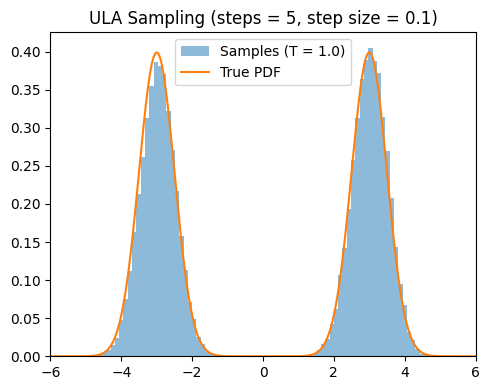

method=ULA, steps=5, step_scale=0.1
mean = 0.125115305185318
var  = 9.222853660583496


In [4]:
methods = ["ULA"]

dataset_names = ["barrier"]
temperature = 2.0

# (n_steps, step_scale, tau)
param_grid = [
    (5, 0.1)
]

def compute_sigma_0(dataset_config):
    """Computes overall standard deviation for dataset according to dataset config parameters"""
    means = np.array(dataset_config['means'])
    stds = dataset_config['stds']
    
    if isinstance(stds, (int, float)):
        stds = np.full_like(means, stds, dtype=float)
    else:
        stds = np.array(stds)
    
    mean_of_mixture = np.mean(means)
    expected_x_squared = np.mean(stds**2 + means**2)
    variance = expected_x_squared - mean_of_mixture**2
    sigma_0 = np.sqrt(variance)
    
    return sigma_0

def compute_tsr(ts_desc, temperature, dataset_config):
    """Computes temporal score rescaling coefficient"""
    # make sure temperature is a tensor on the right device
    temperature = torch.as_tensor(temperature, dtype=torch.float32, device=device)

    temperature_schedule = []
    sigma_0 = compute_sigma_0(dataset_config)   # numpy float
    sigma = torch.as_tensor(sigma_0, dtype=torch.float32, device=device)

    for t in ts_desc:
        a_bar = alpha_bars[t]                   # assume this is already on `device`
        sigma_t = torch.sqrt(1.0 - a_bar)
        alpha_t = torch.sqrt(a_bar)

        eta_t = (alpha_t**2) / (sigma_t**2)
        num = eta_t * (sigma ** 2) + 1
        den = (eta_t * (sigma ** 2)) / temperature + 1

        temperature_schedule.append(num / den)

    return torch.tensor(temperature_schedule)

for method in methods:
	for name in dataset_names:
		dataset_config = DATASETS[name]
		config = (name, dataset_config)
		temperature_schedule = compute_tsr(ts_desc, 1.0, dataset_config)

		for n_steps, scale in param_grid:

			samples = plot_samples(
				config=config,
				temperature=1.0,
				method=method,
				step_scale=scale,
				n_langevin_steps=n_steps,
			)
            
			print(f"method={method}, steps={n_steps}, step_scale={scale}")
			print("mean =", samples.mean().item())
			print("var  =", samples.var().item())